---
date: "2026-08-31"
date-modified: last-modified
format:
  html:
    toc: true
---



# Softmax Optimization, Cross-Entropy Loss, and Extreme Classification

Multi-class classification in deep learning relies on the **softmax function** paired with **cross-entropy loss**. In large-scale recommender and retrieval systems, the output space consists of a massive candidate catalogue of $M \gg 10^7$ items. In this regime, standard full softmax becomes computationally and memory prohibitive.

This note provides a rigorous derivation of cross-entropy loss from Categorical Maximum Likelihood, proves analytical softmax gradient properties, investigates temperature scaling dynamics, analyzes the extreme classification computational bottleneck, and derives Bengio's foundational **$\log Q$ correction** for sampled softmax.

---

## 1\. Categorical Maximum Likelihood & Cross-Entropy Loss Derivation

Let $y \in \{1, 2, \dots, M\}$ denote a discrete class label representing an item chosen from an $M$-element corpus $\mathcal{M}$. Let $\mathbf{z} \equiv (z_1, z_2, \dots, z_M)^T \in \mathbb{R}^{M}$ denote the unnormalized scoring vector (logits) predicted by a neural model.

::: {#def-softmax}
## The Softmax Function
The softmax mapping $\text{softmax}: \mathbb{R}^M \to \Delta^{M-1}$ projects unconstrained logit vectors onto the probability simplex $\Delta^{M-1} = \{ \mathbf{p} \in \mathbb{R}^M \mid p_j \ge 0, \sum_{j=1}^M p_j = 1 \}$:

$$
\hat{y}_j \equiv P(Y = j \mid \mathbf{z}) = \frac{\exp(z_j)}{\sum_{k=1}^M \exp(z_k)} \quad \text{for } j \in \{1, 2, \dots, M\}
$$
:::

### 1.1\. Likelihood Maximization to Cross-Entropy Loss

Represent the true ground-truth label as a one-hot vector $\mathbf{y} \in \{0, 1\}^M$ with $y_j = \mathbb{I}(j = y^*)$. The conditional probability of observing label $y^*$ given logits $\mathbf{z}$ follows a [Categorical distribution](multinomial-distribution.ipynb):

$$
P(Y = y^* \mid \mathbf{z}) = \prod_{j=1}^M \left( \hat{y}_j \right)^{y_j} = \hat{y}_{y^*}
$$

Taking the negative logarithm gives the **Cross-Entropy Loss**:

$$
\mathcal{L}_{\text{CE}}(\mathbf{z}, y^*) \equiv -\ln P(Y = y^* \mid \mathbf{z}) = -\sum_{j=1}^M y_j \ln \hat{y}_j = -\ln \left( \frac{\exp(z_{y^*})}{\sum_{k=1}^M \exp(z_k)} \right)
$$

Expanding the logarithm yields:

$$
\mathcal{L}_{\text{CE}}(\mathbf{z}, y^*) = -z_{y^*} + \ln \left( \sum_{k=1}^M \exp(z_k) \right)
$$



## 2\. Mathematical Properties of the Softmax Function

### 2.1\. Shift Invariance & The Log-Sum-Exp Trick

::: {#prp-softmax-shift-invariance}
## Constant Shift Invariance
For any arbitrary scalar shift $c \in \mathbb{R}$ and all logit vectors $\mathbf{z} \in \mathbb{R}^M$:

$$
\text{softmax}(\mathbf{z} + c \mathbf{1}) = \text{softmax}(\mathbf{z})
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Shift Invariance
Evaluating component $j$:
$$
\frac{\exp(z_j + c)}{\sum_{k=1}^M \exp(z_k + c)} = \frac{\exp(z_j) \cdot e^c}{\sum_{k=1}^M \exp(z_k) \cdot e^c} = \frac{e^c \exp(z_j)}{e^c \sum_{k=1}^M \exp(z_k)} = \frac{\exp(z_j)}{\sum_{k=1}^M \exp(z_k)} = \hat{y}_j \quad \blacksquare
$$
:::

::: {.callout-note}
## Practical Implementation: Numerical Stability via Log-Sum-Exp
In numerical computing, large logits cause floating-point overflow ($\exp(z_j) = \infty$). By setting $c = -\max_{k} z_k$, the shifted logits satisfy $z_j - \max z \le 0$, ensuring $\exp(z_j - \max z) \in (0, 1]$ and preventing overflow.
:::

### 2.2\. Temperature Scaling $\tau > 0$

Introducing a temperature parameter $\tau > 0$ controls the entropy of predicted probabilities:

$$
\hat{y}_j(\tau) = \frac{\exp(z_j / \tau)}{\sum_{k=1}^M \exp(z_k / \tau)}
$$

* **Cold Temperature ($\tau \to 0^+$):** Sharpens probabilities toward a hard argmax (one-hot vector):
  $$
  \lim_{\tau \to 0^+} \hat{y}_j(\tau) = \begin{cases} \frac{1}{|\mathcal{M}_{\max}|} & \text{if } j \in \arg\max_k z_k \\ 0 & \text{otherwise} \end{cases}
  $$
* **Hot Temperature ($\tau \to \infty$):** Flattens the distribution to a uniform distribution:
  $$
  \lim_{\tau \to \infty} \hat{y}_j(\tau) = \frac{1}{M}
  $$



## 3\. Complete Analytical Gradient Derivation

::: {#thm-softmax-gradient}
## Analytical Gradient of Cross-Entropy Loss with Respect to Logits
For any logit index $k \in \{1, 2, \dots, M\}$, the partial derivative of the Cross-Entropy loss with temperature $\tau > 0$ is:

$$
\frac{\partial \mathcal{L}_{\text{CE}}}{\partial z_k} = \frac{1}{\tau} \left( \hat{y}_k - y_k \right) = \frac{1}{\tau} \left( P(Y = k \mid \mathbf{z}) - \mathbb{I}(k = y^*) \right)
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Softmax Analytical Gradient
Write the loss with temperature $\tau$:
$$
\mathcal{L}_{\text{CE}}(\mathbf{z}, y^*) = -\frac{z_{y^*}}{\tau} + \ln \left( \sum_{j=1}^M \exp(z_j / \tau) \right)
$$
Differentiating with respect to $z_k$:
$$
\frac{\partial \mathcal{L}_{\text{CE}}}{\partial z_k} = -\frac{1}{\tau} \frac{\partial z_{y^*}}{\partial z_k} + \frac{\partial}{\partial z_k} \ln \left( \sum_{j=1}^M \exp(z_j / \tau) \right)
$$
Using the chain rule and the Kronecker delta $\frac{\partial z_{y^*}}{\partial z_k} = \delta_{y^*, k} = y_k$:
$$
\begin{aligned}
\frac{\partial \mathcal{L}_{\text{CE}}}{\partial z_k} &= -\frac{y_k}{\tau} + \frac{1}{\sum_{j=1}^M \exp(z_j / \tau)} \cdot \frac{\partial}{\partial z_k} \left( \sum_{j=1}^M \exp(z_j / \tau) \right) \\
&= -\frac{y_k}{\tau} + \frac{1}{\sum_{j=1}^M \exp(z_j / \tau)} \cdot \left( \frac{1}{\tau} \exp(z_k / \tau) \right) \\
&= -\frac{y_k}{\tau} + \frac{1}{\tau} \hat{y}_k \\
&= \frac{1}{\tau} (\hat{y}_k - y_k) \quad \blacksquare
\end{aligned}
$$
:::

### 3.1\. Beautiful Geometric Property: Zero Net Gradient Flux

Summing the partial derivatives across all $M$ classes:

$$
\sum_{k=1}^M \frac{\partial \mathcal{L}_{\text{CE}}}{\partial z_k} = \frac{1}{\tau} \left( \sum_{k=1}^M \hat{y}_k - \sum_{k=1}^M y_k \right) = \frac{1}{\tau} (1 - 1) = 0
$$

The gradient $\nabla_{\mathbf{z}} \mathcal{L}_{\text{CE}}$ is strictly orthogonal to the all-ones vector $\mathbf{1}$, perfectly reflecting the shift-invariance property.



## 4\. The Extreme Classification Bottleneck & Bengio's $\log Q$ Correction

In extreme classification systems (such as YouTube with $M \ge 10^7$ candidate videos), computing the partition function $\sum_{j=1}^M \exp(z_j)$ for every query in a mini-batch of size $B$ requires:

* **Time Complexity:** $\mathcal{O}(B \cdot M \cdot d)$ floating-point operations per step.
* **VRAM Memory Footprint:** Allocating logit matrix $B \times M$ at $B = 4096, M = 10^7$ in FP32 requires $\approx 163.84 \text{ GB}$ VRAM.

### 4.1\. Bengio's Sampled Softmax and $\log Q$ Importance Correction

Bengio & Sénécal (2008) introduced [Importance Sampling](importance-sampling.ipynb) to approximate the partition function by sampling a small subset of $K \ll M$ negative candidate classes according to a proposal distribution $Q = (q_1, \dots, q_M)$:

$$
\sum_{j=1}^M e^{z_j} = \sum_{j=1}^M q_j \frac{e^{z_j}}{q_j} = \mathbb{E}_{j \sim Q} \left[ \frac{e^{z_j}}{q_j} \right] \approx \frac{1}{K} \sum_{j \in \mathcal{S}} \frac{e^{z_j}}{q_j} = \sum_{j \in \mathcal{S}} e^{z_j - \ln(K q_j)}
$$

By adjusting the raw logits with the **$\log Q$ correction**:

$$
z_j^c \equiv z_j - \ln(q_j)
$$

evaluating standard softmax over the small subsampled candidate set $\mathcal{S} \cup \{y^*\}$ yields an **asymptotically unbiased estimator** of the full softmax gradients, unlocking scalable extreme classification.



## 5\. PyTorch Implementation & Scaling Benchmark

We implement:
1. Numerically stable Softmax Cross-Entropy with temperature scaling.
2. Verification of the analytical gradient formula against PyTorch autograd.
3. Computational scaling benchmark demonstrating the extreme classification bottleneck as $M \to 10^6$.


Executing Softmax Benchmarks on: cuda
Max Absolute Error between Autograd & Analytical Gradient: 4.47e-08


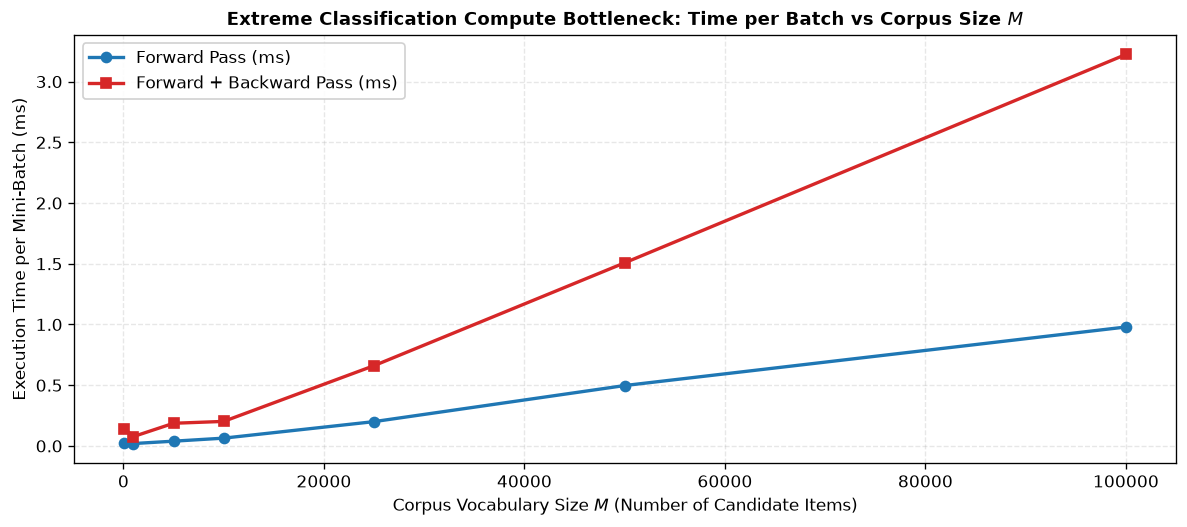

In [1]:
import torch
import torch.nn as nn
import time
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing Softmax Benchmarks on: {device}")

# 1. Custom Numerically Stable LogSoftmax Cross Entropy with Temperature
def stable_cross_entropy_with_temperature(logits, targets, tau=1.0):
    # Scale logits by temperature
    scaled_logits = logits / tau
    # Log-Sum-Exp trick: subtract max logit for numerical stability
    max_logits, _ = torch.max(scaled_logits, dim=-1, keepdim=True)
    shifted_logits = scaled_logits - max_logits
    log_sum_exp = torch.log(torch.sum(torch.exp(shifted_logits), dim=-1, keepdim=True))
    log_probs = shifted_logits - log_sum_exp
    
    # Negative log-likelihood of target
    loss = -torch.gather(log_probs, dim=-1, index=targets.unsqueeze(-1)).squeeze(-1)
    return torch.mean(loss)

# 2. Gradient Verification
batch_size = 4
num_classes = 5
tau = 0.5

torch.manual_seed(42)
z = torch.randn(batch_size, num_classes, device=device, requires_grad=True)
targets = torch.tensor([1, 0, 4, 2], device=device)

# Compute loss and autograd gradient
loss = stable_cross_entropy_with_temperature(z, targets, tau=tau)
loss.backward()
autograd_grad = z.grad.clone()

# Compute analytical gradient: (1/tau) * (softmax(z/tau) - one_hot) / batch_size
with torch.no_grad():
    probs = torch.softmax(z / tau, dim=-1)
    one_hot = torch.zeros_like(probs)
    one_hot.scatter_(1, targets.unsqueeze(1), 1.0)
    analytical_grad = (probs - one_hot) / (tau * batch_size)

grad_error = torch.max(torch.abs(autograd_grad - analytical_grad)).item()
print(f"Max Absolute Error between Autograd & Analytical Gradient: {grad_error:.2e}")

# 3. Computational Scaling Wall Benchmark
M_values = [100, 1000, 5000, 10000, 25000, 50000, 100000]
forward_times = []
backward_times = []
B = 256
d = 128

for M in M_values:
    # Query representations: B x d, Candidate weights: M x d
    queries = torch.randn(B, d, device=device, requires_grad=True)
    candidates = torch.randn(M, d, device=device, requires_grad=True)
    labels = torch.randint(0, M, (B,), device=device)
    
    # Warmup
    logits = torch.matmul(queries, candidates.T)
    loss = nn.functional.cross_entropy(logits, labels)
    loss.backward()
    
    # Benchmark
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(10):
        logits = torch.matmul(queries, candidates.T)
        loss = nn.functional.cross_entropy(logits, labels)
    if device.type == "cuda":
        torch.cuda.synchronize()
    t_fwd = (time.time() - t0) / 10.0
    
    t0 = time.time()
    for _ in range(10):
        logits = torch.matmul(queries, candidates.T)
        loss = nn.functional.cross_entropy(logits, labels)
        loss.backward()
    if device.type == "cuda":
        torch.cuda.synchronize()
    t_bwd = (time.time() - t0) / 10.0
    
    forward_times.append(t_fwd * 1000)  # ms
    backward_times.append(t_bwd * 1000) # ms

# Visualizing Scaling Wall
plt.figure(figsize=(10, 4.5), dpi=120)
plt.plot(M_values, forward_times, 'o-', label='Forward Pass (ms)', color='#1f77b4', lw=2)
plt.plot(M_values, backward_times, 's-', label='Forward + Backward Pass (ms)', color='#d62728', lw=2)
plt.title(r'Extreme Classification Compute Bottleneck: Time per Batch vs Corpus Size $M$', fontsize=11, fontweight='bold')
plt.xlabel('Corpus Vocabulary Size $M$ (Number of Candidate Items)', fontsize=10)
plt.ylabel('Execution Time per Mini-Batch (ms)', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


---

> **References & Acknowledgments:**
> 
> * Prince, Simon J.D. *Understanding Deep Learning*, MIT Press, 2023. Chapter 5: Loss Functions.
> * Bengio, Yoshua, and Jean-Sébastien Sénécal. "Adaptive importance sampling to accelerate training of a neural probabilistic language model." *IEEE Transactions on Neural Networks* 19.4 (2008): 713-722.
> * Goodfellow, Ian, Yoshua Bengio, and Aaron Courville. *Deep Learning*, MIT Press, 2016. Chapter 6: Deep Feedforward Networks.
